In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
np.random.seed(42)
num_customers = 1000

age = np.random.choice([25, 32, 41, 45], size=num_customers, p=[0.25, 0.25, 0.25, 0.25]) + np.random.randint(-3, 4, num_customers)
income = np.random.choice([25.7, 26.3, 86.5, 88.5], size=num_customers, p=[0.25, 0.25, 0.25, 0.25]) * 1000 + np.random.normal(0, 3000, num_customers)
spending_score = np.random.choice([17, 20, 79, 82], size=num_customers, p=[0.25, 0.25, 0.25, 0.25]) + np.random.randint(-5, 6, num_customers)

df = pd.DataFrame({
    'Age': np.clip(age, 18, 70),
    'Annual_Income': np.clip(income, 15000, 120000),
    'Spending_Score': np.clip(spending_score, 1, 100)
})
df

,Age,Annual_Income,Spending_Score
0,35,28318.757560,20
1,45,84610.284236,79
2,43,25835.226194,13
3,40,88602.208855,82
4,28,24864.826488,74
...,...,...,...
995,25,21795.969419,81
996,45,27153.339816,84
997,28,27684.998884,79
998,43,23923.373281,16


In [3]:
df.isna().sum()

Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

In [4]:
df.describe()

,Age,Annual_Income,Spending_Score
count,1000.000000,1000.000000,1000.000000
mean,35.559000,56886.529278,49.246000
std,8.193268,31036.698553,31.002268
min,22.000000,16325.732840,12.000000
25%,28.000000,25796.012452,19.000000
50%,35.000000,79787.445047,25.000000
75%,43.000000,87850.056649,80.000000
max,48.000000,95730.145948,87.000000


## Standardization

In [5]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X = std.fit_transform(df)
type(X),X.shape

(numpy.ndarray, (1000, 3))

# PCA

In [6]:
from sklearn.decomposition import PCA

In [7]:
pca = PCA(n_components = 0.95, random_state = 42)
X_transformed = pca.fit_transform(X)
df_pca = pd.DataFrame(X_transformed)
df_pca

,0,1,2
0,-0.928078,-0.614869,0.710032
1,1.663542,0.524988,0.082677
2,-0.371053,-0.907720,1.494721
3,1.355085,0.642530,-0.455614
4,-1.096642,1.161589,-0.061832
...,...,...,...
995,-1.351128,1.443732,-0.286897
996,0.477591,1.228650,1.329676
997,-0.990281,1.287706,-0.145995
998,-0.384503,-0.797518,1.523812


In [8]:
variance = pca.explained_variance_ratio_
variance

array([0.35830735, 0.33156374, 0.31012891])

In [9]:
np.cumsum(np.round(variance,decimals = 4)*100)

array([ 35.83,  68.99, 100.  ])

# K Means

In [10]:
model1 = KMeans(n_clusters = 2)
target = model1.fit_predict(df_pca)

In [11]:
df['Target'] = target
df

,Age,Annual_Income,Spending_Score,Target
0,35,28318.757560,20,1
1,45,84610.284236,79,0
2,43,25835.226194,13,1
3,40,88602.208855,82,0
4,28,24864.826488,74,0
...,...,...,...,...
995,25,21795.969419,81,0
996,45,27153.339816,84,0
997,28,27684.998884,79,0
998,43,23923.373281,16,1


In [12]:
model1.cluster_centers_, model1.inertia_

(array([[ 0.30642837,  0.94352885, -0.12495737],
        [-0.30277317, -0.93227403,  0.12346682]]),
 2012.1661774582592)

In [13]:
df_pca

,0,1,2
0,-0.928078,-0.614869,0.710032
1,1.663542,0.524988,0.082677
2,-0.371053,-0.907720,1.494721
3,1.355085,0.642530,-0.455614
4,-1.096642,1.161589,-0.061832
...,...,...,...
995,-1.351128,1.443732,-0.286897
996,0.477591,1.228650,1.329676
997,-0.990281,1.287706,-0.145995
998,-0.384503,-0.797518,1.523812


In [14]:
wcss = []
for i in range(2,11):
    model = KMeans(n_clusters = i)
    model.fit(df_pca)
    wcss.append(model.inertia_)

In [15]:
wcss

[2181.5170637432725,
 1604.932193457666,
 1015.5806577108202,
 814.8035075325515,
 621.3424319400724,
 416.151717640245,
 208.21303553070513,
 179.827746474945,
 163.85799084458304]

# Elbow Method

In [16]:
import matplotlib.pyplot as plt

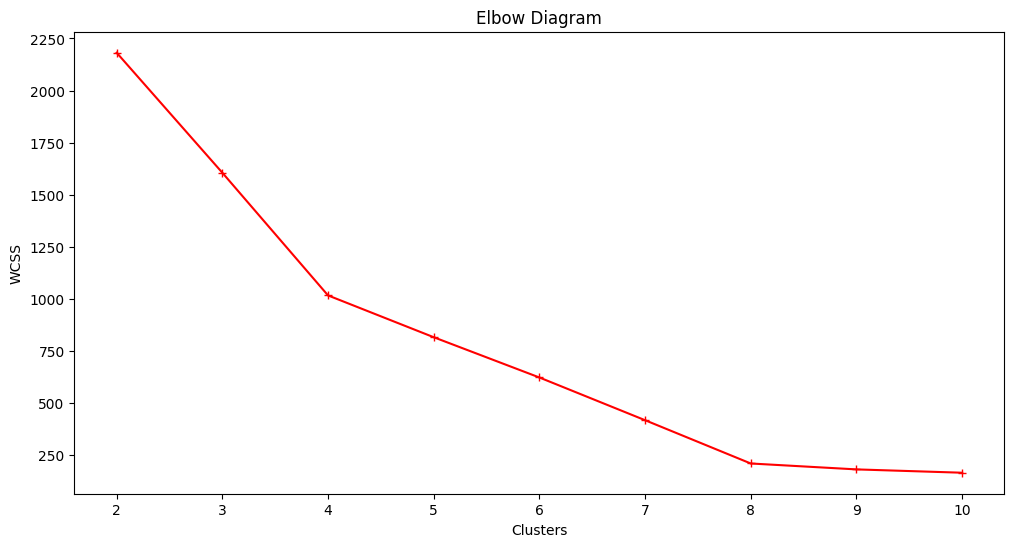

In [17]:
plt.figure(figsize = (12,6))
plt.plot(range(2,11),wcss,color="red",marker = '+')
plt.title("Elbow Diagram")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

### optimal_cluster = 4 as per the elbow method


In [18]:
final_model = KMeans(n_clusters = 4, random_state = 42)

In [19]:
clusters = final_model.fit_predict(df_pca)
clusters

array([0, 1, 2, 1, 0, 1, 3, 2, 2, 2, 1, 1, 1, 0, 0, 3, 0, 1, 0, 1, 2, 0,
       1, 3, 1, 2, 0, 3, 3, 0, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 3, 0, 1, 1,
       3, 1, 0, 2, 3, 1, 1, 1, 1, 2, 2, 1, 1, 0, 3, 0, 1, 0, 2, 1, 0, 3,
       3, 1, 0, 2, 2, 1, 3, 1, 3, 3, 3, 0, 1, 0, 3, 1, 3, 0, 0, 0, 2, 2,
       3, 1, 0, 2, 2, 1, 3, 1, 2, 1, 3, 0, 1, 2, 3, 2, 3, 1, 1, 3, 0, 0,
       0, 0, 1, 2, 3, 3, 1, 0, 3, 3, 2, 1, 3, 0, 3, 0, 2, 2, 0, 2, 0, 3,
       3, 1, 2, 0, 1, 2, 0, 3, 2, 3, 1, 0, 0, 1, 2, 2, 3, 0, 1, 3, 0, 0,
       2, 0, 2, 1, 0, 3, 3, 3, 3, 2, 3, 1, 0, 0, 3, 2, 2, 0, 2, 1, 3, 3,
       2, 0, 2, 0, 0, 1, 2, 3, 0, 2, 2, 1, 1, 1, 0, 2, 3, 2, 3, 0, 2, 2,
       2, 3, 2, 0, 0, 2, 1, 1, 3, 3, 0, 3, 2, 2, 1, 0, 3, 0, 1, 1, 1, 1,
       3, 2, 3, 0, 1, 3, 3, 0, 2, 1, 2, 2, 2, 1, 1, 2, 0, 0, 1, 1, 2, 2,
       2, 1, 3, 2, 0, 2, 1, 2, 3, 3, 2, 0, 0, 1, 3, 3, 1, 0, 3, 3, 0, 3,
       3, 1, 3, 1, 3, 0, 2, 1, 2, 2, 2, 2, 1, 3, 2, 2, 2, 1, 3, 0, 1, 3,
       1, 1, 0, 1, 0, 1, 1, 3, 3, 2, 3, 1, 1, 0, 0,

In [20]:
df['Target'] = clusters
df.head()

,Age,Annual_Income,Spending_Score,Target
0,35,28318.757560,20,0
1,45,84610.284236,79,1
2,43,25835.226194,13,2
3,40,88602.208855,82,1
4,28,24864.826488,74,0


In [21]:
pca_centriods = final_model.cluster_centers_
pca_centriods

array([[-1.29268099,  0.40226361,  0.01879873],
       [ 1.01631145,  0.64446738, -0.72935837],
       [-0.06057915,  0.17293443,  1.34951659],
       [ 0.40594285, -1.23528532, -0.51605933]])

In [22]:
scaled_centriods = pca.inverse_transform(pca_centriods)
scaled_centriods

array([[-0.92121887, -0.99217771,  0.01152093],
       [ 0.11225323,  0.98403603,  0.99963148],
       [ 0.90597279, -1.01620842, -0.03612389],
       [ 0.0402295 ,  0.99068551, -0.98689435]])

In [23]:
original_centriods = std.inverse_transform(scaled_centriods)
original_centriods

array([[2.80149813e+01, 2.61080095e+04, 4.96029963e+01],
       [3.64782609e+01, 8.74124844e+04, 8.02213439e+01],
       [4.29781659e+01, 2.53625487e+04, 4.81266376e+01],
       [3.58884462e+01, 8.76187591e+04, 1.86653386e+01]])

In [24]:
features = ['Age','Income','Spending_Score']
final_df = pd.DataFrame(original_centriods,columns = features)
final_df

,Age,Income,Spending_Score
0,28.014981,26108.009507,49.602996
1,36.478261,87412.484433,80.221344
2,42.978166,25362.548658,48.126638
3,35.888446,87618.759105,18.665339


In [25]:
final_df['Suggested_Persona'] = [
    'The Affluent Conservatives', 
    'The High-Value Trendsetters', 
    'The Budget-Conscious Explorers', 
    'The Conservative Minimizers'
]

print(final_df.set_index('Suggested_Persona'))

                                      Age        Income  Spending_Score
Suggested_Persona                                                      
The Affluent Conservatives      28.014981  26108.009507       49.602996
The High-Value Trendsetters     36.478261  87412.484433       80.221344
The Budget-Conscious Explorers  42.978166  25362.548658       48.126638
The Conservative Minimizers     35.888446  87618.759105       18.665339


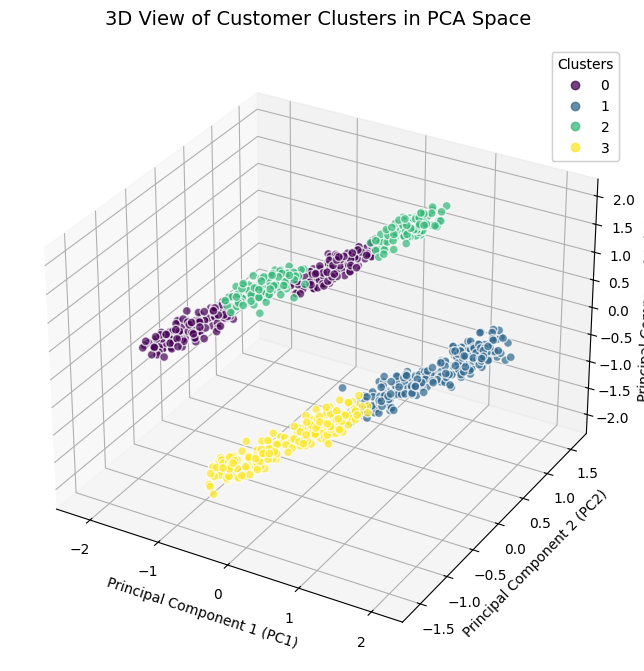

In [31]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pca.iloc[:, 0],  
    df_pca.iloc[:, 1],  
    df_pca.iloc[:, 2],  
    c=df['Target'],    
    cmap='viridis',     
    s=40,               
    alpha=0.7, 
    edgecolors='w'
)


ax.set_title('3D View of Customer Clusters in PCA Space', fontsize=14, pad=15)
ax.set_xlabel('Principal Component 1 (PC1)', fontsize=10)
ax.set_ylabel('Principal Component 2 (PC2)', fontsize=10)
ax.set_zlabel('Principal Component 3 (PC3)', fontsize=10)

legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
ax.add_artist(legend)

plt.show()